<a href="https://colab.research.google.com/github/poojakesarkar27/CSL701-CS24_Machine-Learning-Lab/blob/experiments-ml/Experiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name :Pooja rupesh Kesarkar

Batch : CS24



### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import networkx as nx

from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

df = pd.read_csv("/content/brca.csv")

print("Dataset loaded successfully")
print(df.head())

Dataset loaded successfully
   Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0           1         13.540           14.36             87.46        566.3   
1           2         13.080           15.71             85.63        520.0   
2           3          9.504           12.44             60.34        273.9   
3           4         13.030           18.42             82.61        523.8   
4           5          8.196           16.84             51.71        201.9   

   x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
0            0.09779             0.08129           0.06664   
1            0.10750             0.12700           0.04568   
2            0.10240             0.06492           0.02956   
3            0.08983             0.03766           0.02562   
4            0.08600             0.05943           0.01588   

   x.concave_pts_mean  x.symmetry_mean  ...  x.texture_worst  \
0            0.047810           0.1885  ...            19.26

# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

print("\nFeature Dimensions:")
print(df.shape)

print("\nClass Distribution:")
print(df["y"].value_counts())

Missing Values:
Unnamed: 0             0
x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se              0
x.smoothness_se        0
x.compactness_se       0
x.concavity_se         0
x.concave_pts_se       0
x.symmetry_se          0
x.fractal_dim_se       0
x.radius_worst         0
x.texture_worst        0
x.perimeter_worst      0
x.area_worst           0
x.smoothness_worst     0
x.compactness_worst    0
x.concavity_worst      0
x.concave_pts_worst    0
x.symmetry_worst       0
x.fractal_dim_worst    0
y                      0
dtype: int64

Summary Statistics:
       Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  \
count  569.000000     569.000000      569.000000        569.000000   
mean   285

# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [ ]:
# Remove ID and target column
X = df.drop(columns=["Unnamed: 0", "y"])

# Store target labels
y = df["y"]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original feature shape:", X.shape)
print("Scaled feature shape:", X_scaled.shape)

Original feature shape: (569, 30)
Scaled feature shape: (569, 30)


# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [ ]:
# Compute pairwise Euclidean distances
distance_matrix = squareform(pdist(X_scaled, metric="euclidean"))

print("Distance Matrix Shape:", distance_matrix.shape)

# Create weighted graph
G = nx.from_numpy_array(distance_matrix)

print("Number of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())

Distance Matrix Shape: (569, 569)
Number of Nodes: 569
Number of Edges: 161596


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [ ]:
# Compute Minimum Spanning Tree
mst = minimum_spanning_tree(distance_matrix)

# Convert MST to NetworkX graph
MST_graph = nx.from_scipy_sparse_array(mst)

print("Number of MST Nodes:", MST_graph.number_of_nodes())
print("Number of MST Edges:", MST_graph.number_of_edges())

# Display first 10 MST edges with weights
print("\nFirst 10 MST Edges:")
for u, v, data in list(MST_graph.edges(data=True))[:10]:
    print(u, v, round(data["weight"], 4))

Number of MST Nodes: 569
Number of MST Edges: 568

First 10 MST Edges:
0 81 1.6886
0 108 2.1714
1 105 1.6607
2 70 2.2189
3 170 2.3462
3 222 2.5415
4 84 2.166
4 279 1.8603
5 125 1.7659
5 172 2.0171


# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [ ]:
# Copy MST graph
clustered_graph = MST_graph.copy()

# Sort edges by weight in descending order
edges = sorted(
    clustered_graph.edges(data=True),
    key=lambda x: x[2]["weight"],
    reverse=True
)

# Remove the largest edge
largest_edge = edges[0]
clustered_graph.remove_edge(largest_edge[0], largest_edge[1])

# Find connected components
components = list(nx.connected_components(clustered_graph))

# Assign cluster labels
cluster_labels = np.zeros(len(df), dtype=int)

for cluster_id, component in enumerate(components):
    for node in component:
        cluster_labels[node] = cluster_id

print("Number of Clusters:", len(components))
print("Cluster Sizes:", [len(c) for c in components])

Number of Clusters: 2
Cluster Sizes: [567, 2]


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [ ]:
# Calculate evaluation metrics
silhouette = silhouette_score(X_scaled, cluster_labels)

ari = adjusted_rand_score(y, cluster_labels)

nmi = normalized_mutual_info_score(y, cluster_labels)

print("Silhouette Score:", silhouette)
print("Adjusted Rand Index (ARI):", ari)
print("Normalized Mutual Information (NMI):", nmi)

Silhouette Score: 0.6606668813897673
Adjusted Rand Index (ARI): 0.0048283446965917305
Normalized Mutual Information (NMI): 0.010182219220269649


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

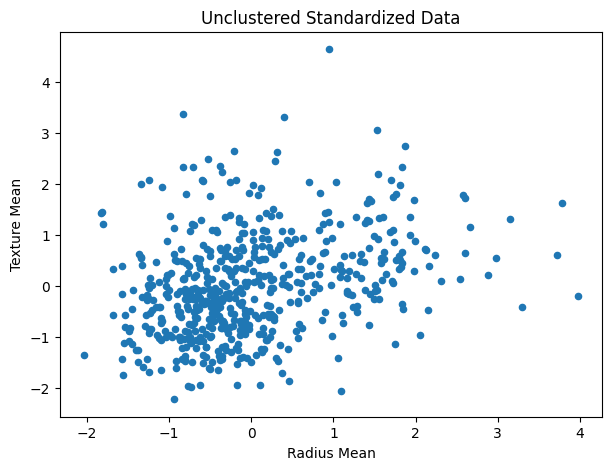

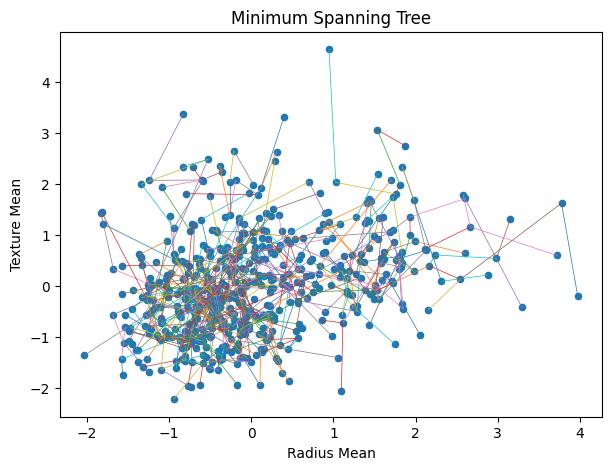

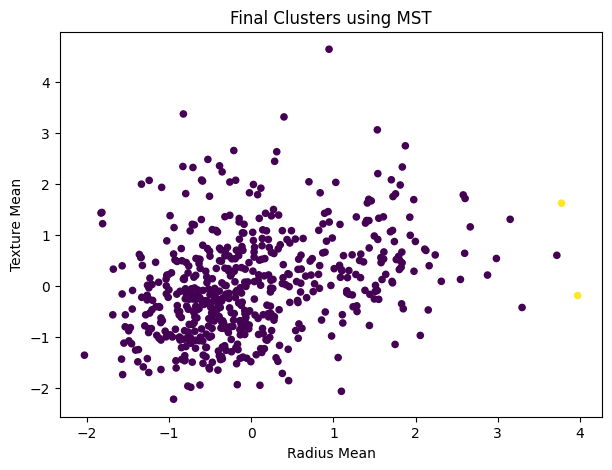

In [ ]:
# 1. Unclustered standardized data
plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=20)
plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.title("Unclustered Standardized Data")
plt.show()


# 2. MST visualization
plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=20)

for u, v in MST_graph.edges():
    plt.plot(
        [X_scaled[u, 0], X_scaled[v, 0]],
        [X_scaled[u, 1], X_scaled[v, 1]],
        linewidth=0.5
    )

plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.title("Minimum Spanning Tree")
plt.show()


# 3. Final clusters
plt.figure(figsize=(7, 5))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=cluster_labels,
    s=20
)

plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.title("Final Clusters using MST")
plt.show()

# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.